In [ ]:
# Cell 1: Install Roboflow & download (only run if you need to re-download)
!pip install -q roboflow

from roboflow import Roboflow
from pathlib import Path

# --------- USER: update ONLY if you need to re-download ----------
ROBOFLOW_API_KEY = "okQU2itAKp5MnUF9FR9g"   # your key (keep private)
WORKSPACE = "parin-kittipongdaja-vwmn3"
PROJECT = "skin-problem-multilabel"
VERSION = 1
# ---------------------------------------------------------------

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace(WORKSPACE).project(PROJECT)
version = project.version(VERSION)
dataset = version.download("folder")   # "folder" format -> train/valid/test
print("Downloaded dataset to:", dataset.location)
INPUT_DIR = Path(dataset.location)
print("INPUT_DIR:", INPUT_DIR)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 48.0 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Skin-Problem-MultiLabel-1 in folder:: 100%|██████████| 4906/4906 [00:00<00:00, 6232.07it/s]

Downloaded dataset to: /content/Skin-Problem-MultiLabel-1
INPUT_DIR: /content/Skin-Problem-MultiLabel-1


In [ ]:
# Cell 2: imports, seeds, paths
import os, random, shutil
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers, applications, preprocessing
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight

# reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# ---------- USER: point to your dataset root here ----------
DATA_DIR = Path('/content/Skin-Problem-MultiLabel-1')   # change if needed
TRAIN_DIR = DATA_DIR / 'train'
VAL_DIR   = DATA_DIR / 'valid'   # Roboflow uses 'valid' usually; adjust if yours is 'val'
TEST_DIR  = DATA_DIR / 'test'
# ----------------------------------------------------------

for p in (DATA_DIR, TRAIN_DIR, VAL_DIR, TEST_DIR):
    print(p, "exists:", p.exists())


/content/Skin-Problem-MultiLabel-1 exists: True
/content/Skin-Problem-MultiLabel-1/train exists: True
/content/Skin-Problem-MultiLabel-1/valid exists: True
/content/Skin-Problem-MultiLabel-1/test exists: True


Classes: ['Acne', 'Acne Dark Spots', 'Acne Dry Skin', 'Acne Dry Skin Eye bags Pores', 'Acne Dry Skin Pores', 'Acne Eye bags', 'Acne Eye bags Pores', 'Acne Eye bags Pores Wrinkles', 'Acne Eye bags Wrinkles', 'Acne Oily Skin', 'Acne Oily Skin Pores', 'Acne Pores', 'Acne Pores Wrinkles', 'Acne Wrinkles', 'Blackheads', 'Dark Spots', 'Dry Skin', 'Dry Skin Wrinkles', 'Eye bags', 'Eye bags Pores', 'Eye bags Pores Wrinkles', 'Normal Skin', 'Oily Skin', 'Oily Skin Pores', 'Pores', 'Pores Wrinkles', 'Skin Redness', 'Wrinkles']
Train counts: {'Acne': 1848, 'Acne Dark Spots': 8, 'Acne Dry Skin': 5, 'Acne Dry Skin Eye bags Pores': 2, 'Acne Dry Skin Pores': 4, 'Acne Eye bags': 31, 'Acne Eye bags Pores': 13, 'Acne Eye bags Pores Wrinkles': 12, 'Acne Eye bags Wrinkles': 7, 'Acne Oily Skin': 17, 'Acne Oily Skin Pores': 3, 'Acne Pores': 110, 'Acne Pores Wrinkles': 21, 'Acne Wrinkles': 24, 'Blackheads': 72, 'Dark Spots': 182, 'Dry Skin': 314, 'Dry Skin Wrinkles': 1, 'Eye bags': 87, 'Eye bags Pores': 2, '

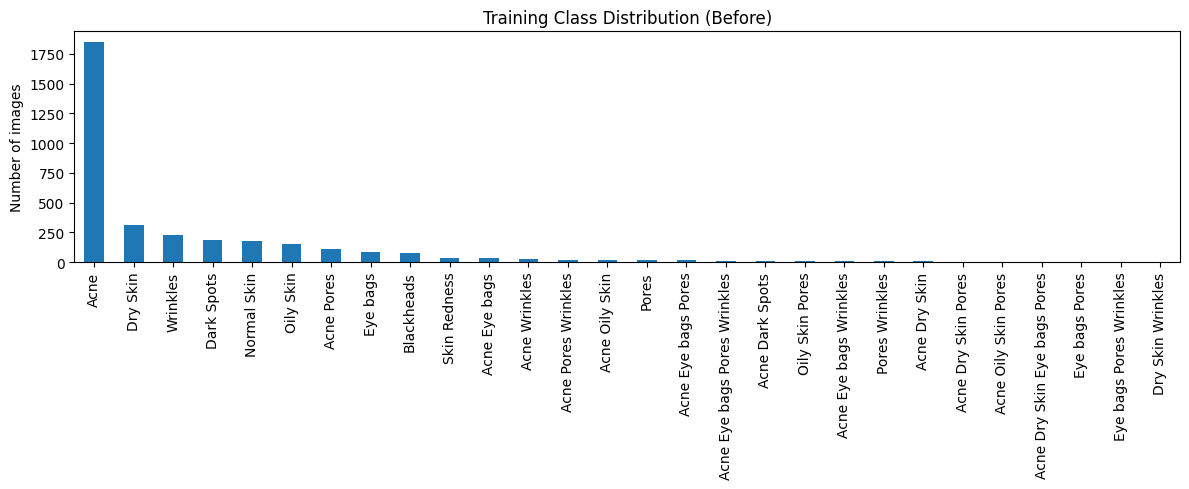

In [ ]:
# Cell 3: EDA helper and BEFORE plot
def class_counts_from_folder(folder: Path):
    classes = []
    counts = {}
    if folder.exists():
        for cls in sorted([d.name for d in folder.iterdir() if d.is_dir()]):
            n = len(list((folder/cls).glob('*')))
            classes.append(cls)
            counts[cls] = n
    return classes, counts

classes, train_counts = class_counts_from_folder(TRAIN_DIR)
_, val_counts = class_counts_from_folder(VAL_DIR)
_, test_counts = class_counts_from_folder(TEST_DIR)

print("Classes:", classes)
print("Train counts:", train_counts)
print("Val counts:  ", val_counts)
print("Test counts: ", test_counts)

# bar plot (before)
if train_counts:
    pd.Series(train_counts).sort_values(ascending=False).plot(kind='bar', figsize=(12,5))
    plt.title('Training Class Distribution (Before)')
    plt.ylabel('Number of images')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()


In [ ]:
# Cell 4: Merge mapping & move extremely rare classes (<=3) to 'Other'
def merge_and_clean(base_dir: Path):
    mapping = {
        # Acne group -> "Acne"
        "Acne Dark Spots": "Acne",
        "Acne Dry Skin": "Acne",
        "Acne Dry Skin Eye bags Pores": "Acne",
        "Acne Dry Skin Pores": "Acne",
        "Acne Eye bags": "Acne",
        "Acne Eye bags Pores": "Acne",
        "Acne Eye bags Pores Wrinkles": "Acne",
        "Acne Eye bags Wrinkles": "Acne",
        "Acne Oily Skin": "Acne",
        "Acne Oily Skin Pores": "Acne",
        "Acne Pores": "Acne",
        "Acne Pores Wrinkles": "Acne",
        "Acne Wrinkles": "Acne",
        # skin types
        "Dry Skin Wrinkles": "Dry Skin",
        "Oily Skin Pores": "Oily Skin",
        "Eye bags Pores": "Eye bags",
        "Eye bags Pores Wrinkles": "Eye bags",
        "Pores Wrinkles": "Pores"
    }

    other_dir = base_dir / "Other"
    other_dir.mkdir(exist_ok=True)

    for cls in [d.name for d in base_dir.iterdir() if d.is_dir()]:
        cls_path = base_dir / cls

        # mapping merge
        if cls in mapping:
            target = base_dir / mapping[cls]
            target.mkdir(exist_ok=True)
            for f in cls_path.glob('*'):
                # Check if the destination file exists before moving
                if not (target / f.name).exists():
                    shutil.move(str(f), str(target))
                else:
                    print(f"Skipping move for {f} as destination {target / f.name} already exists.")
            try:
                os.rmdir(cls_path)
            except OSError:
                pass
            continue

        # move tiny classes to Other
        n_imgs = len(list(cls_path.glob('*')))
        if n_imgs <= 3:
            for f in cls_path.glob('*'):
                # Check if the destination file exists before moving
                if not (other_dir / f.name).exists():
                    shutil.move(str(f), str(other_dir))
                else:
                     print(f"Skipping move for {f} as destination {other_dir / f.name} already exists.")
            try:
                os.rmdir(cls_path)
            except OSError:
                pass

# Apply to all splits if they exist
for d in (TRAIN_DIR, VAL_DIR, TEST_DIR):
    if d.exists():
        print("Cleaning:", d)
        merge_and_clean(d)

# refresh counts
classes, train_counts = class_counts_from_folder(TRAIN_DIR)
print("Train counts after merge/clean:", train_counts)

Cleaning: /content/Skin-Problem-MultiLabel-1/train
Cleaning: /content/Skin-Problem-MultiLabel-1/valid
Cleaning: /content/Skin-Problem-MultiLabel-1/test
Skipping move for /content/Skin-Problem-MultiLabel-1/test/Other/42_jpg.rf.6a9212f297f1351ce97270d119629cd7.jpg as destination /content/Skin-Problem-MultiLabel-1/test/Other/42_jpg.rf.6a9212f297f1351ce97270d119629cd7.jpg already exists.
Train counts after merge/clean: {'Acne': 2105, 'Blackheads': 72, 'Dark Spots': 182, 'Dry Skin': 315, 'Eye bags': 91, 'Normal Skin': 178, 'Oily Skin': 159, 'Pores': 20, 'Skin Redness': 32, 'Wrinkles': 224}


In [ ]:
# Cell 5: compute a sensible TARGET for balancing (between MIN_TARGET and MAX_TARGET)
MIN_TARGET = 200
MAX_TARGET = 700
counts_arr = np.array(list(train_counts.values())) if train_counts else np.array([0])
median_count = int(np.median(counts_arr))
auto_target = int(median_count * 2)
TARGET = max(MIN_TARGET, min(MAX_TARGET, auto_target))
print(f"median = {median_count}, auto_target = {auto_target}, USING TARGET = {TARGET}")


median = 168, auto_target = 336, USING TARGET = 336


Acne counts -> original (est): 2105, current: 2105, backup: 0


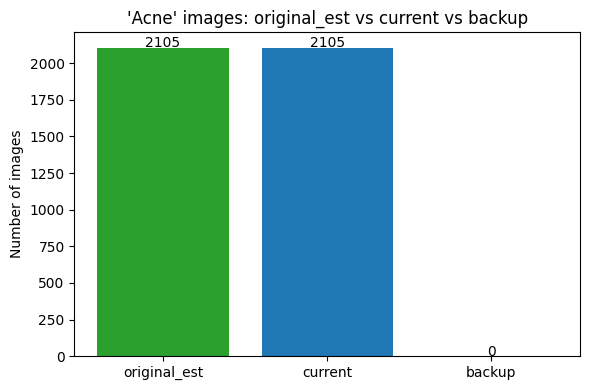

In [ ]:
# Cell B: visualize undersampling effect for TARGET_CLASS (Acne)
import matplotlib.pyplot as plt
from pathlib import Path

TARGET_CLASS = globals().get('TARGET_CLASS', 'Acne')
backup_dir = globals().get('backup_dir', TRAIN_DIR / f"_{TARGET_CLASS.lower()}_undersample_backup")

acne_dir = TRAIN_DIR / TARGET_CLASS
current_acne = len(list(acne_dir.glob('*'))) if acne_dir.exists() else 0
backup_count = len(list(Path(backup_dir).glob('*'))) if Path(backup_dir).exists() else 0
original_est = current_acne + backup_count

print(f"{TARGET_CLASS} counts -> original (est): {original_est}, current: {current_acne}, backup: {backup_count}")

# bar plot before vs after
plt.figure(figsize=(6,4))
plt.bar(['original_est','current','backup'], [original_est, current_acne, backup_count], color=['#2ca02c','#1f77b4','#ff7f0e'])
plt.title(f"'{TARGET_CLASS}' images: original_est vs current vs backup")
plt.ylabel('Number of images')
for i,val in enumerate([original_est, current_acne, backup_count]):
    plt.text(i, val+2, str(val), ha='center')
plt.tight_layout()
plt.show()


In [ ]:
# Cell 6: safe undersample (move extras to backup) instead of deleting
TARGET_CLASS = "Acne"
backup_dir = TRAIN_DIR / f"_{TARGET_CLASS.lower()}_undersample_backup"
backup_dir.mkdir(exist_ok=True)

acne_dir = TRAIN_DIR / TARGET_CLASS
if acne_dir.exists():
    acne_files = list(acne_dir.glob('*'))
    n_acne = len(acne_files)
    print(f"Acne count before undersample: {n_acne}")
    if n_acne > TARGET:
        n_to_move = n_acne - TARGET
        to_move = random.sample(acne_files, n_to_move)
        moved = 0
        for f in to_move:
            try:
                shutil.move(str(f), str(backup_dir))
                moved += 1
            except Exception as e:
                print("move error:", f, e)
        print(f"Moved {moved} Acne images to {backup_dir}")
    else:
        print("No undersampling needed for Acne.")
else:
    print("Acne folder not found; skipping undersample.")


Acne count before undersample: 2105
Moved 1769 Acne images to /content/Skin-Problem-MultiLabel-1/train/_acne_undersample_backup


In [ ]:
# Cell 7: augmentation helper and run for classes with less than TARGET images
datagen = ImageDataGenerator(
    rotation_range=18,
    width_shift_range=0.10,
    height_shift_range=0.10,
    shear_range=0.06,
    zoom_range=0.12,
    horizontal_flip=True,
    fill_mode='nearest'
)

def augment_folder_to_target(folder: Path, current_count: int, target: int, per_image_limit=3):
    if not folder.exists():
        return 0
    created = 0
    src_images = list(folder.glob('*'))
    if len(src_images) == 0:
        return 0
    idx = 0
    while current_count + created < target:
        src = src_images[idx % len(src_images)]
        idx += 1
        try:
            img = Image.open(src).convert('RGB')
            x = np.expand_dims(np.array(img), 0)
            gen = datagen.flow(x, batch_size=1)
            n_gen = min(per_image_limit, target - (current_count + created))
            for _ in range(n_gen):
                batch = next(gen)
                arr = (batch[0]).astype(np.uint8)
                new_name = folder / f"aug_{src.stem}_{random.getrandbits(32)}.jpg"
                Image.fromarray(arr).save(new_name)
                created += 1
        except Exception as e:
            print("augment error on", src, e)
            continue
    return created

# run augmentation for classes below TARGET (skip TARGET_CLASS)
train_counts = class_counts_from_folder(TRAIN_DIR)[1]  # refresh
augmented_summary = {}
for cls, cnt in train_counts.items():
    if cls == TARGET_CLASS or cls.startswith('_'):
        continue
    if cnt < TARGET:
        folder = TRAIN_DIR / cls
        print(f"\nAugmenting '{cls}': {cnt} -> {TARGET}")
        created = augment_folder_to_target(folder, cnt, TARGET, per_image_limit=3)
        augmented_summary[cls] = created
        print(f"  created {created} images for '{cls}'")
    else:
        print(f"\nClass '{cls}' has {cnt} images (>= TARGET). Skipping augmentation.")



Augmenting 'Blackheads': 72 -> 336
  created 264 images for 'Blackheads'

Augmenting 'Dark Spots': 182 -> 336
  created 154 images for 'Dark Spots'

Augmenting 'Dry Skin': 315 -> 336
  created 21 images for 'Dry Skin'

Augmenting 'Eye bags': 91 -> 336
  created 245 images for 'Eye bags'

Augmenting 'Normal Skin': 178 -> 336
  created 158 images for 'Normal Skin'

Augmenting 'Oily Skin': 159 -> 336
  created 177 images for 'Oily Skin'

Augmenting 'Pores': 20 -> 336
  created 316 images for 'Pores'

Augmenting 'Skin Redness': 32 -> 336
  created 304 images for 'Skin Redness'

Augmenting 'Wrinkles': 224 -> 336
  created 112 images for 'Wrinkles'


Augmented images per class (top):
Pores           316
Skin Redness    304
Blackheads      264
Eye bags        245
Oily Skin       177
Normal Skin     158
Dark Spots      154
Wrinkles        112
Dry Skin         21
dtype: int64


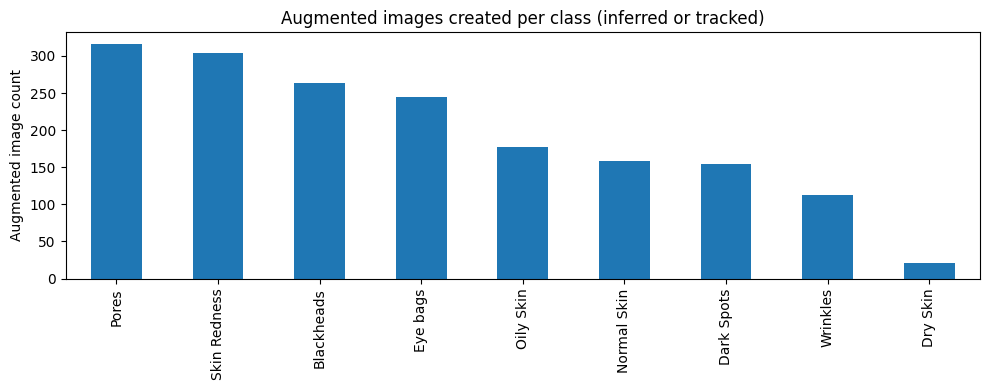

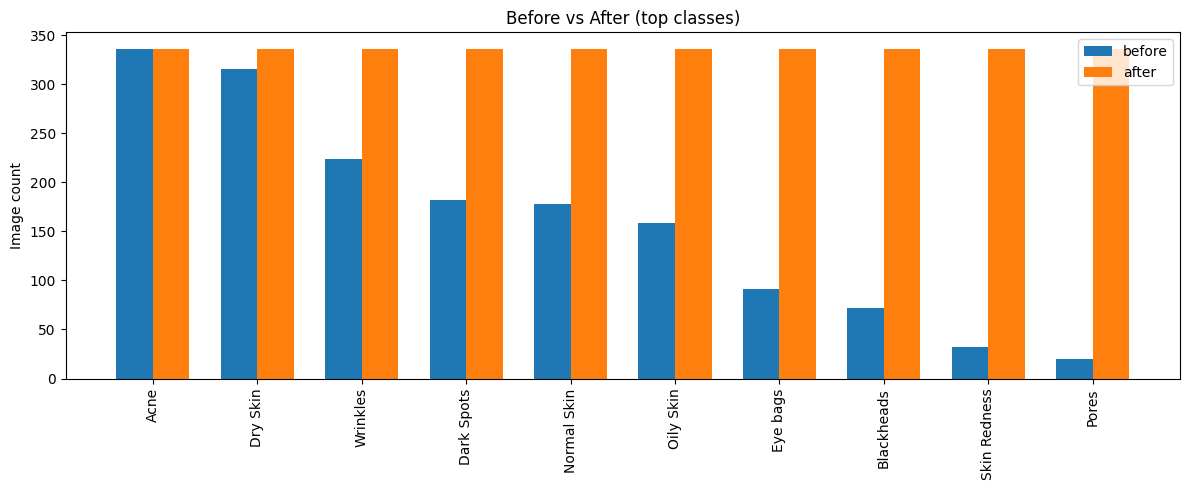

In [ ]:
# Cell C: augmentation progress per class and before->after bar
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Helper function to get counts from a folder
def get_counts(folder: Path):
    counts = {}
    if folder.exists():
        for cls in sorted([d.name for d in folder.iterdir() if d.is_dir()]):
            n = len(list((folder/cls).glob('*')))
            counts[cls] = n
    return counts


# recompute counts before augmentation if possible:
# If augmented_summary exists we assume we stored it; if not, try to reconstruct by checking 'aug_' prefix count difference
aug_summary = globals().get('augmented_summary', None)

# get counts AFTER
counts_after = get_counts(TRAIN_DIR)

# Try to infer created counts: count files with 'aug_' prefix per class
inferred_aug = {}
for cls in counts_after.keys():
    if cls.startswith('_'):
        continue
    folder = TRAIN_DIR / cls
    aug_files = [p for p in folder.glob('aug_*') if p.is_file()]
    inferred_aug[cls] = len(aug_files)

# prefer augmented_summary if available and non-empty
aug_used = aug_summary if (aug_summary and isinstance(aug_summary, dict) and len(aug_summary)>0) else inferred_aug

# Build dataframe for display
df_aug = pd.Series(aug_used).sort_values(ascending=False)
print("Augmented images per class (top):")
print(df_aug.head(20))

# plot augmented counts
plt.figure(figsize=(10,4))
df_aug.plot(kind='bar')
plt.title('Augmented images created per class (inferred or tracked)')
plt.ylabel('Augmented image count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# If we have a record of original counts (estimated via backup + current for Acne, and by subtracting aug_ files for others),
# produce a before vs after bar for non-underscore classes.
before_counts = {}
for cls,curr in counts_after.items():
    if cls.startswith('_'):
        continue
    created = aug_used.get(cls, 0)
    before_counts[cls] = max(0, curr - created)

df_before = pd.Series(before_counts).sort_values(ascending=False)
df_after  = pd.Series({k:counts_after[k] for k in df_before.index})

# show side-by-side before/after for top classes
top = df_after.sort_values(ascending=False).head(12).index
plt.figure(figsize=(12,5))
x = np.arange(len(top))
width=0.35
plt.bar(x - width/2, df_before[top].values, width, label='before')
plt.bar(x + width/2, df_after[top].values, width, label='after')
plt.xticks(x, top, rotation=90)
plt.ylabel('Image count')
plt.title('Before vs After (top classes)')
plt.legend()
plt.tight_layout()
plt.show()


Counts AFTER:
  Acne: 336
  Blackheads: 336
  Dark Spots: 336
  Dry Skin: 336
  Eye bags: 336
  Normal Skin: 336
  Oily Skin: 336
  Pores: 336
  Skin Redness: 336
  Wrinkles: 336
  _acne_undersample_backup: 1769


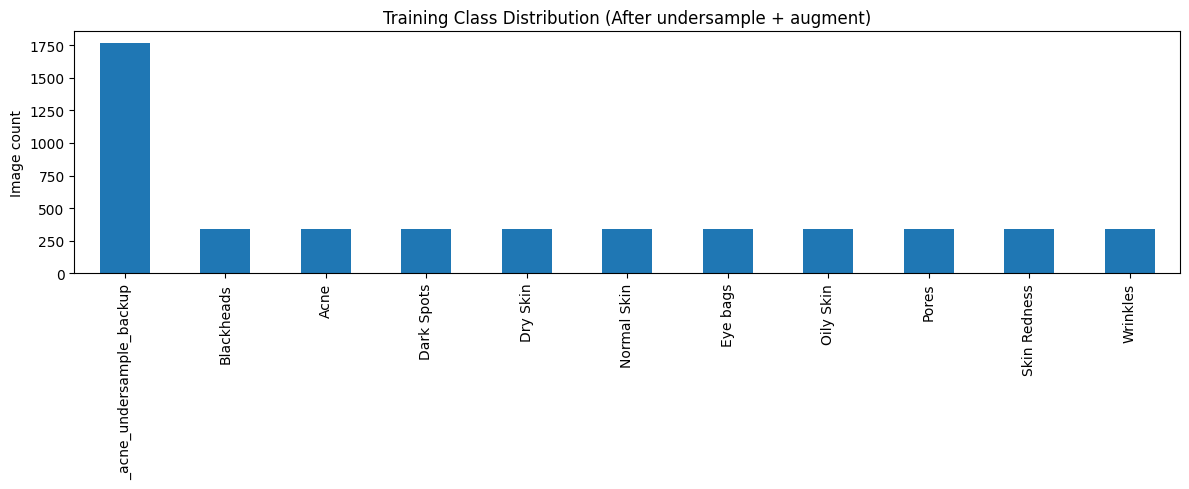


Augmentation summary (class -> created):
  Blackheads -> 264
  Dark Spots -> 154
  Dry Skin -> 21
  Eye bags -> 245
  Normal Skin -> 158
  Oily Skin -> 177
  Pores -> 316
  Skin Redness -> 304
  Wrinkles -> 112

Backup for moved Acne images: /content/Skin-Problem-MultiLabel-1/train/_acne_undersample_backup


In [ ]:
# Cell 8: print & plot counts after balancing steps
classes_after, train_counts_after = class_counts_from_folder(TRAIN_DIR)
print("\nCounts AFTER:")
for k,v in train_counts_after.items():
    print(f"  {k}: {v}")

plt.figure(figsize=(12,5))
pd.Series(train_counts_after).sort_values(ascending=False).plot(kind='bar')
plt.title('Training Class Distribution (After undersample + augment)')
plt.ylabel('Image count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print("\nAugmentation summary (class -> created):")
for k,v in augmented_summary.items():
    print(" ", k, "->", v)

print("\nBackup for moved Acne images:", backup_dir)


Summary stats (train):


,0
count,11.000000
mean,466.272727
std,432.065757
min,336.000000
25%,336.000000
50%,336.000000
75%,336.000000
max,1769.000000


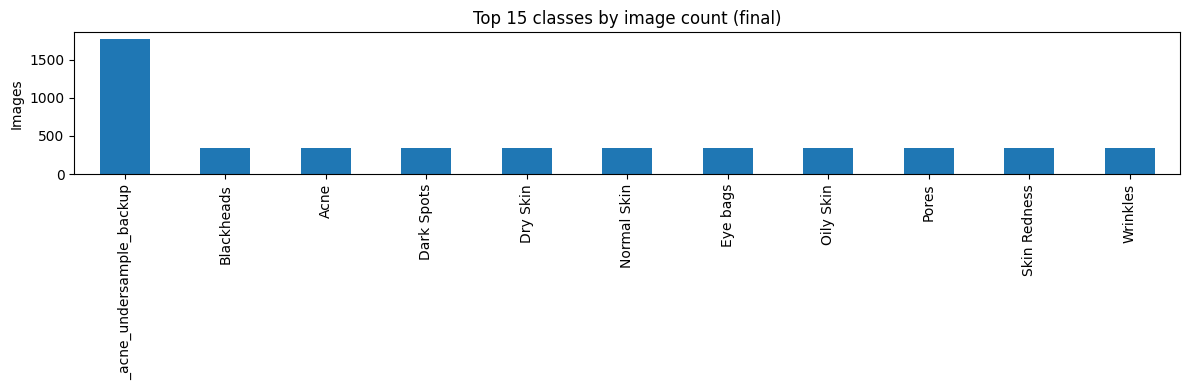

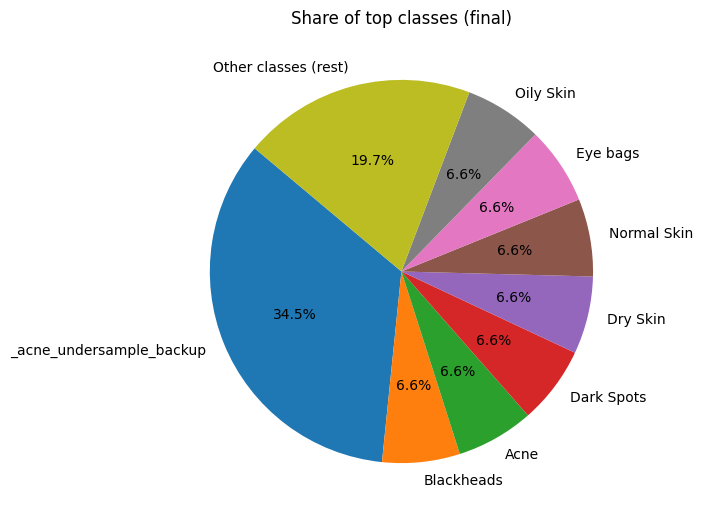


No classes with less than 100 images.


In [ ]:
# Cell D: Final distribution summary and plots
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

counts_final = get_counts(TRAIN_DIR)
series_final = pd.Series(counts_final).sort_values(ascending=False)

print("Summary stats (train):")
display(series_final.describe())

# bar chart (top 15)
plt.figure(figsize=(12,4))
series_final.head(15).plot(kind='bar')
plt.title('Top 15 classes by image count (final)')
plt.ylabel('Images')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# pie chart for top 8 + rest
topn = 8
top = series_final.head(topn)
rest_sum = series_final.iloc[topn:].sum()
pie_vals = list(top.values) + [rest_sum]
pie_labels = list(top.index) + ['Other classes (rest)']
plt.figure(figsize=(7,7))
plt.pie(pie_vals, labels=pie_labels, autopct='%1.1f%%', startangle=140)
plt.title('Share of top classes (final)')
plt.tight_layout()
plt.show()

# show classes that are still low (< threshold)
LOW_SHOW = 100
low_classes = series_final[series_final < LOW_SHOW]
if len(low_classes):
    print(f"\nClasses with < {LOW_SHOW} images:")
    display(low_classes.sort_values())
else:
    print(f"\nNo classes with less than {LOW_SHOW} images.")


In [ ]:
# Cell 9: create stratified validation split (optional) if VAL_DIR is empty/nonexistent
from math import floor
VAL_FRAC = 0.15  # fraction of each class to move

if not VAL_DIR.exists() or not any(VAL_DIR.iterdir()):
    print("VAL_DIR is empty or missing; creating stratified validation split from TRAIN_DIR...")
    VAL_DIR.mkdir(parents=True, exist_ok=True)
    train_counts_post = class_counts_from_folder(TRAIN_DIR)[1]
    for cls, cnt in train_counts_post.items():
        if cls.startswith('_'):
            continue
        cls_train_dir = TRAIN_DIR / cls
        cls_val_dir = VAL_DIR / cls
        cls_val_dir.mkdir(parents=True, exist_ok=True)
        n_to_move = max(1, floor(cnt * VAL_FRAC)) if cnt > 1 else 0
        if n_to_move > 0:
            imgs = list(cls_train_dir.glob('*'))
            if len(imgs) <= n_to_move:
                selection = imgs[:-1] if len(imgs) > 1 else imgs
            else:
                selection = random.sample(imgs, n_to_move)
            moved = 0
            for f in selection:
                try:
                    shutil.move(str(f), str(cls_val_dir))
                    moved += 1
                except Exception as e:
                    print("val move error:", f, e)
            if moved:
                print(f"Moved {moved} images of '{cls}' to validation.")
else:
    print("VAL_DIR already contains files; skipping stratified split.")


VAL_DIR already contains files; skipping stratified split.


In [ ]:
from pathlib import Path
import shutil

TRAIN_DIR = Path("/content/Skin-Problem-MultiLabel-1/train")   # adjust if needed
BACKUP = TRAIN_DIR / "_acne_undersample_backup"
SAFE_BACKUP_LOCATION = TRAIN_DIR.parent / "backups"           # e.g. /content/Skin-Problem-MultiLabel-1/backups

SAFE_BACKUP_LOCATION.mkdir(exist_ok=True, parents=True)

if BACKUP.exists():
    try:
        shutil.move(str(BACKUP), str(SAFE_BACKUP_LOCATION))
        print("Moved backup to:", SAFE_BACKUP_LOCATION)
    except Exception as e:
        print("Move error:", e)
else:
    print("No backup folder found at", BACKUP)


Moved backup to: /content/Skin-Problem-MultiLabel-1/backups


In [ ]:
# Cell 10: generators setup
IMAGE_SIZE = (224,224)
BATCH_SIZE = 16

train_datagen = preprocessing.image.ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.06,
    height_shift_range=0.06,
    zoom_range=0.06,
    horizontal_flip=True,
    preprocessing_function=applications.mobilenet.preprocess_input
)

val_datagen = preprocessing.image.ImageDataGenerator(
    preprocessing_function=applications.mobilenet.preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    str(TRAIN_DIR),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    str(VAL_DIR),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_datagen.flow_from_directory(
    str(TEST_DIR),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("Train samples:", train_generator.samples)
print("Val samples:  ", val_generator.samples)
print("Test samples: ", test_generator.samples)
CLASS_NAMES = list(train_generator.class_indices.keys())
print("Class order (index -> name):", train_generator.class_indices)


Found 3360 images belonging to 10 classes.
Found 969 images belonging to 10 classes.
Found 481 images belonging to 10 classes.
Train samples: 3360
Val samples:   969
Test samples:  481
Class order (index -> name): {'Acne': 0, 'Blackheads': 1, 'Dark Spots': 2, 'Dry Skin': 3, 'Eye bags': 4, 'Normal Skin': 5, 'Oily Skin': 6, 'Pores': 7, 'Skin Redness': 8, 'Wrinkles': 9}


In [ ]:
# Cell 11: compute class weights based on train_generator.classes
y_train = train_generator.classes
cw = compute_class_weight(class_weight='balanced',
                          classes=np.unique(y_train),
                          y=y_train)
class_weights = {i: float(w) for i,w in enumerate(cw)}
print("Class weights:", class_weights)
# Use class_weights in model.fit


Class weights: {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0, 5: 1.0, 6: 1.0, 7: 1.0, 8: 1.0, 9: 1.0}


In [ ]:
from tensorflow.keras import regularizers
from tensorflow.keras import applications

# choose smaller head to reduce overfitting
HEAD_UNITS = 128   # try 128 (or 64)
DROPOUT_RATE = 0.2
L2 = 1e-4          # weight decay for dense layers

# reuse your existing base_model (assumes it's MobileNet with include_top=False)
# If base_model is not in memory, rebuild it and load imagenet weights exactly as before.
# Example (uncomment if needed):
# from tensorflow.keras import applications
base_model = applications.MobileNet(input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3),
                                    include_top=False, weights='imagenet', pooling='avg')
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = layers.Dropout(0.4)(x)
x = layers.Dense(HEAD_UNITS, activation='relu',
                 kernel_regularizer=regularizers.l2(L2),
                 bias_regularizer=regularizers.l2(L2))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(DROPOUT_RATE)(x)
outputs = layers.Dense(len(CLASS_NAMES), activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=outputs)

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',  
    metrics=['categorical_accuracy',
             tf.keras.metrics.TopKCategoricalAccuracy(k=2, name='top_2_accuracy')]
)

# quick param check
trainable_count = int(np.sum([tf.keras.backend.count_params(w) for w in model.trainable_weights]))
total_count = int(np.sum([tf.keras.backend.count_params(w) for w in model.weights]))
print("Total params:", total_count)
print("Trainable params:", trainable_count)
model.summary()

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Total params: 3361866
Trainable params: 132746


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 112, 112, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 112, 112, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 112, 112, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 112, 112, 64)   │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 113, 113, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 56, 56, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 56, 56, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 56, 56, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 56, 56, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 3,361,866 (12.82 MB)

 Trainable params: 132,746 (518.54 KB)

 Non-trainable params: 3,229,120 (12.32 MB)

In [ ]:
# Callbacks
checkpoint = callbacks.ModelCheckpoint('best_head_only.h5', monitor='val_top_2_accuracy',
                                       save_best_only=True, mode='max', verbose=1)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_top_2_accuracy', factor=0.5,
                                        patience=2, min_lr=1e-6, mode='max', verbose=1)
earlystop = callbacks.EarlyStopping(monitor='val_top_2_accuracy', patience=4,
                                    restore_best_weights=True, mode='max', verbose=1)

EPOCHS_HEAD = 10
history_head = model.fit(
    train_generator,
    epochs=EPOCHS_HEAD,
    steps_per_epoch = int(np.ceil(train_generator.samples / BATCH_SIZE)),
    validation_data = val_generator,
    validation_steps = int(np.ceil(val_generator.samples / BATCH_SIZE)),
    class_weight = class_weights,
    callbacks=[checkpoint, reduce_lr, earlystop]
)


Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.


Epoch 1/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - categorical_accuracy: 0.1814 - loss: 2.8200 - top_2_accuracy: 0.3008
Epoch 1: val_top_2_accuracy improved from -inf to 0.48710, saving model to best_head_only.h5


210/210 ━━━━━━━━━━━━━━━━━━━━ 75s 282ms/step - categorical_accuracy: 0.1815 - loss: 2.8192 - top_2_accuracy: 0.3009 - val_categorical_accuracy: 0.3230 - val_loss: 2.0061 - val_top_2_accuracy: 0.4871 - learning_rate: 1.0000e-04
Epoch 2/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - categorical_accuracy: 0.3079 - loss: 2.1964 - top_2_accuracy: 0.4561
Epoch 2: val_top_2_accuracy improved from 0.48710 to 0.59236, saving model to best_head_only.h5


210/210 ━━━━━━━━━━━━━━━━━━━━ 46s 220ms/step - categorical_accuracy: 0.3080 - loss: 2.1959 - top_2_accuracy: 0.4563 - val_categorical_accuracy: 0.4417 - val_loss: 1.6929 - val_top_2_accuracy: 0.5924 - learning_rate: 1.0000e-04
Epoch 3/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - categorical_accuracy: 0.4000 - loss: 1.8378 - top_2_accuracy: 0.5603
Epoch 3: val_top_2_accuracy improved from 0.59236 to 0.61713, saving model to best_head_only.h5


210/210 ━━━━━━━━━━━━━━━━━━━━ 47s 225ms/step - categorical_accuracy: 0.4001 - loss: 1.8376 - top_2_accuracy: 0.5604 - val_categorical_accuracy: 0.4665 - val_loss: 1.6057 - val_top_2_accuracy: 0.6171 - learning_rate: 1.0000e-04
Epoch 4/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - categorical_accuracy: 0.4494 - loss: 1.6739 - top_2_accuracy: 0.6176
Epoch 4: val_top_2_accuracy improved from 0.61713 to 0.70175, saving model to best_head_only.h5


...

210/210 ━━━━━━━━━━━━━━━━━━━━ 82s 227ms/step - categorical_accuracy: 0.5306 - loss: 1.4201 - top_2_accuracy: 0.7096 - val_categorical_accuracy: 0.5676 - val_loss: 1.2875 - val_top_2_accuracy: 0.7337 - learning_rate: 1.0000e-04
Epoch 7/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - categorical_accuracy: 0.5788 - loss: 1.2983 - top_2_accuracy: 0.7360
Epoch 7: val_top_2_accuracy improved from 0.73375 to 0.76058, saving model to best_head_only.h5


210/210 ━━━━━━━━━━━━━━━━━━━━ 48s 227ms/step - categorical_accuracy: 0.5788 - loss: 1.2983 - top_2_accuracy: 0.7360 - val_categorical_accuracy: 0.5831 - val_loss: 1.2238 - val_top_2_accuracy: 0.7606 - learning_rate: 1.0000e-04
Epoch 8/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - categorical_accuracy: 0.5753 - loss: 1.2787 - top_2_accuracy: 0.7416
Epoch 8: val_top_2_accuracy improved from 0.76058 to 0.77090, saving model to best_head_only.h5


210/210 ━━━━━━━━━━━━━━━━━━━━ 48s 227ms/step - categorical_accuracy: 0.5753 - loss: 1.2787 - top_2_accuracy: 0.7416 - val_categorical_accuracy: 0.6037 - val_loss: 1.1638 - val_top_2_accuracy: 0.7709 - learning_rate: 1.0000e-04
Epoch 9/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - categorical_accuracy: 0.6134 - loss: 1.1977 - top_2_accuracy: 0.7897
Epoch 9: val_top_2_accuracy improved from 0.77090 to 0.77915, saving model to best_head_only.h5


210/210 ━━━━━━━━━━━━━━━━━━━━ 48s 231ms/step - categorical_accuracy: 0.6134 - loss: 1.1977 - top_2_accuracy: 0.7897 - val_categorical_accuracy: 0.6109 - val_loss: 1.1287 - val_top_2_accuracy: 0.7792 - learning_rate: 1.0000e-04
Epoch 10/10
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - categorical_accuracy: 0.6185 - loss: 1.1377 - top_2_accuracy: 0.7907
Epoch 10: val_top_2_accuracy improved from 0.77915 to 0.79670, saving model to best_head_only.h5


210/210 ━━━━━━━━━━━━━━━━━━━━ 47s 226ms/step - categorical_accuracy: 0.6185 - loss: 1.1376 - top_2_accuracy: 0.7907 - val_categorical_accuracy: 0.6223 - val_loss: 1.1019 - val_top_2_accuracy: 0.7967 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 10.


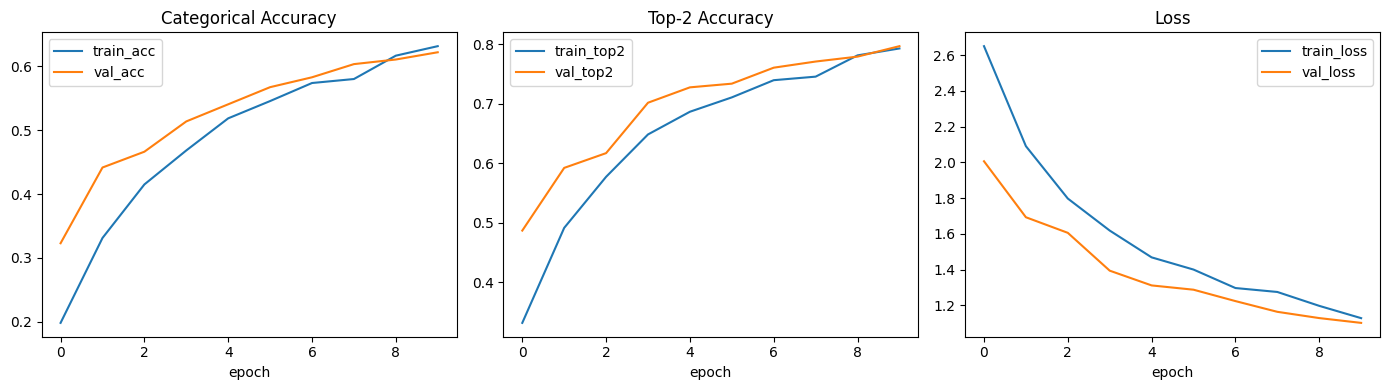

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# assumes history_head exists
h = history_head.history

plt.figure(figsize=(14,4))

# categorical accuracy
plt.subplot(1,3,1)
plt.plot(h.get('categorical_accuracy', []), label='train_acc')
plt.plot(h.get('val_categorical_accuracy', []), label='val_acc')
plt.title('Categorical Accuracy')
plt.xlabel('epoch')
plt.legend()

# top-2 accuracy
plt.subplot(1,3,2)
plt.plot(h.get('top_2_accuracy', []), label='train_top2')
plt.plot(h.get('val_top_2_accuracy', []), label='val_top2')
plt.title('Top-2 Accuracy')
plt.xlabel('epoch')
plt.legend()

# loss
plt.subplot(1,3,3)
plt.plot(h.get('loss', []), label='train_loss')
plt.plot(h.get('val_loss', []), label='val_loss')
plt.title('Loss')
plt.xlabel('epoch')
plt.legend()

plt.tight_layout()
plt.show()


 1/31 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - categorical_accuracy: 0.2500 - loss: 1.7494 - top_2_accuracy: 0.5625

Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.


31/31 ━━━━━━━━━━━━━━━━━━━━ 13s 422ms/step - categorical_accuracy: 0.5115 - loss: 1.3527 - top_2_accuracy: 0.7268
Test eval (loss, categorical_accuracy, top_2_accuracy): [1.0533461570739746, 0.6590436697006226, 0.8066527843475342]
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 137ms/step

Classification Report:
              precision    recall  f1-score   support

        Acne      0.990     0.625     0.766       312
  Blackheads      0.391     0.750     0.514        12
  Dark Spots      0.293     0.667     0.407        18
    Dry Skin      0.449     0.524     0.484        42
    Eye bags      0.318     0.875     0.467         8
 Normal Skin      0.771     1.000     0.871        27
   Oily Skin      0.773     0.654     0.708        26
       Pores      0.000     0.000     0.000         1
Skin Redness      0.088     0.600     0.154         5
    Wrinkles      0.735     0.833     0.781        30

    accuracy                          0.659       481
   macro avg      0.481     0.653     0.515       481
w

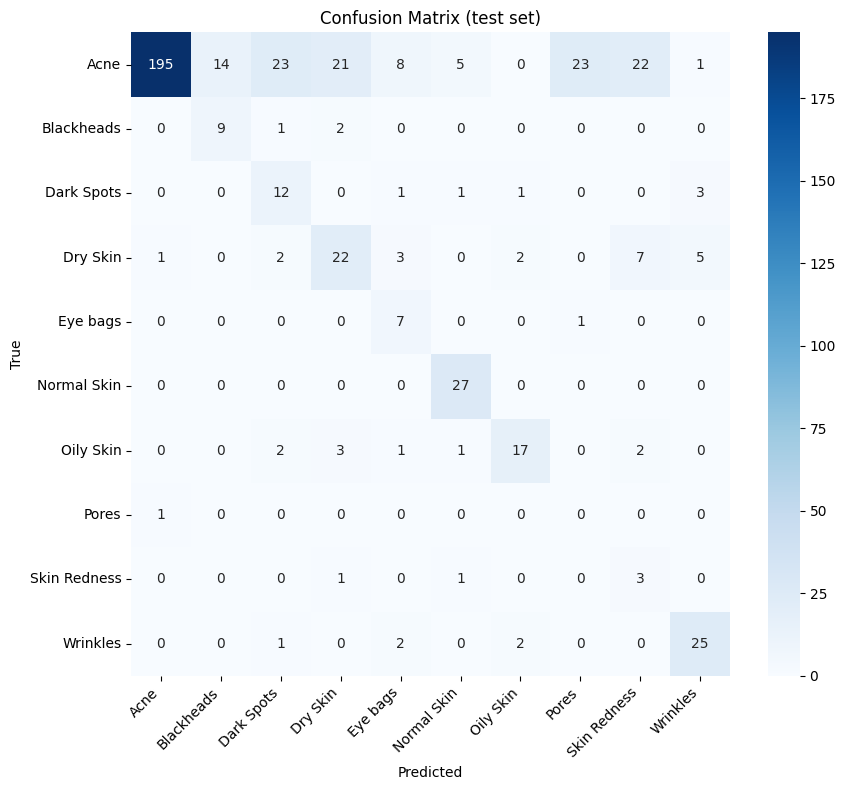

In [ ]:
# Cell: evaluate and detailed metrics
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# load best weights (if not loaded). Adjust path if needed:
best_ckpt = 'best_head_only.h5'   # or path from your callbacks
model.load_weights(best_ckpt)

# evaluate
res = model.evaluate(test_generator, verbose=1)
print("Test eval (loss, categorical_accuracy, top_2_accuracy):", res)

# predict
y_prob = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_prob, axis=1)
y_true = test_generator.classes
class_idx = {v:k for k,v in train_generator.class_indices.items()}
class_names = [class_idx[i] for i in range(len(class_idx))]

# classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

# confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (test set)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
best_h5 = 'best_head_only.h5'
best_keras = 'best_head_only.keras'
if Path(best_h5).exists():
    # load and resave in native format
    model.load_weights(best_h5)
    model.save(best_keras)
    print("Saved native Keras model to", best_keras)
else:
    print("Best .h5 not found:", best_h5)


Saved native Keras model to best_head_only.keras


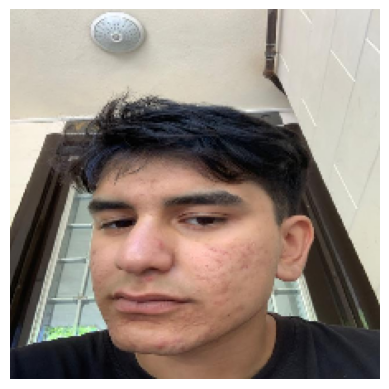

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step

🧠 Predicted Disease Probabilities (%):

Acne: 13.98%
Blackheads: 0.15%
Dark Spots: 0.26%
Dry Skin: 0.29%
Eye Bags: 4.71%
Normal Skin: 1.11%
Oily Skin: 0.26%
Pores: 70.54%
Skin Redness: 0.42%
Wrinkles: 8.29%


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# ✅ Load your trained model (if not already loaded)
from tensorflow.keras.models import load_model
model = load_model("/content/best_head_only.h5")  # change filename if needed

# ✅ Define class names (same order used during training)
class_names = ['Acne', 'Blackheads', 'Dark Spots', 'Dry Skin',
               'Eye Bags', 'Normal Skin', 'Oily Skin',
               'Pores', 'Skin Redness', 'Wrinkles']

# ✅ Function to predict disease probabilities
def predict_face_disease(img_path):
    img = image.load_img(img_path, target_size=(224, 224))  # adjust size to match your model
    plt.imshow(img)
    plt.axis("off")
    plt.show()

    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_array)[0]  # get probabilities
    results = dict(zip(class_names, preds * 100))

    print("\n🧠 Predicted Disease Probabilities (%):\n")
    for k, v in results.items():
        print(f"{k}: {v:.2f}%")

# ✅ Example usage:
predict_face_disease("/content/Skin-Problem-MultiLabel-1/test/Acne/150_jpg.rf.d9c8b4833925e2c339404ae0ac3dbf2b.jpg")


In [ ]:
import random
import os
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Get a list of all image paths in the test directory
test_image_paths = []
for class_name in CLASS_NAMES:
    class_path = os.path.join(TEST_DIR, class_name)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            if img_name.endswith(('.jpg', '.jpeg', '.png')):
                test_image_paths.append(os.path.join(class_path, img_name))

# Select 4 random images
random_image_paths = random.sample(test_image_paths, 4)

# Classify and display each image
for img_path in random_image_paths:
    img = image.load_img(img_path, target_size=IMAGE_SIZE)

    # Display the image
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = applications.mobilenet.preprocess_input(x)

    images = np.vstack([x])
    classes = model.predict(images, batch_size=10)

    print(os.path.basename(img_path))
    # Print the top 2 predicted classes and their probabilities
    top_2_indices = np.argsort(classes[0])[-2:][::-1]
    top_2_probs = np.sort(classes[0])[-2:][::-1]

    print("Predictions:")
    for i in range(2):
        class_name = CLASS_NAMES[top_2_indices[i]]
        probability = top_2_probs[i]
        print(f"  {class_name}: {probability:.4f}")
    print("-" * 20) # Separator for clarity

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import shutil
from pathlib import Path

# Path to the trained model file
model_path = Path('best_head_only.keras') # or 'best_head_only.h5' if you prefer the H5 format

# Destination path in your Google Drive
# Make sure this directory exists in your Drive, or change the path as needed
drive_destination_dir = Path('/content/drive/MyDrive/Skin_Problem_Model')
drive_destination_dir.mkdir(parents=True, exist_ok=True) # Create the directory if it doesn't exist

# Copy the model file to Google Drive
try:
    shutil.copy(str(model_path), str(drive_destination_dir / model_path.name))
    print(f"Model saved successfully to: {drive_destination_dir / model_path.name}")
except Exception as e:
    print(f"Error saving model to Google Drive: {e}")

Model saved successfully to: /content/drive/MyDrive/Skin_Problem_Model/best_head_only.keras
